## Process SFNO data for selected flooding events

- Useful data locations on s3
    - Desmond simulation initialised at 00Z on 23 Nov 2015 (34 checkpoints): `s3://jba-stress-testing/desmond/global/`
    - Desmond different initialisation times: `s3://jba-stress-testing/event_response/global/`
    - TC Charley from October 1986: `s3://jba-stress-testing/charley_1986/global/`
    - August 2015 non-event (looking for events that plausibly could have happened): `s3://jba-stress-testing/dublin_2015/global/` 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import math

import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
try:
    # MetPy import (works for different MetPy versions)
    from metpy.plots import ctables
except Exception as exc:
    raise ImportError("MetPy is required to use MetPy color tables") from exc

import logging
import glob
import os
import re
import metpy.plots.ctables as mp
from pathlib import Path
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
sns.set_theme()

import plotting_functions as pf

## Load metadata from the config file

- `file_path`, `date_str`, `event_name`

In [2]:
config_file_path = '/mnt/data/data_analysis/config.json'
events = pf.load_config(config_file_path)
event_str = 'Desmond' # ['21Aug2015', '22Aug2015', 'Charley_20Aug1986', 'Desmond', 'Desmond_seed76', 'event_response'] 
file_path = events[event_str]['path']
files = sorted(glob.glob(f'{file_path}/*.nc'))
date_str = events[event_str]['date_str']
event_name = events[event_str]['name']

## Plotting functions for SFNO data

- Postage stamp plot of all ensemble members (`produce_postage_stamp_plot`), either mean sea level pressure (`mslp`) or 6-h accumulated precip (`pr`)
- Smaller plot containing the most extreme ensemble members at a selected time (`find_and_plot_top_members`)
- TODO: include an argument that specifies a bounding box for plotting as well as subsetting for the rainfall calculation

In [3]:
# if event_str == 'Desmond_seed76' or event_str == 'Desmond_seed76_v2':
#     region_extent=[-20, 10.0, 65.0, 45.0]
#     uk_extent=[-12.5, 6.5, 60.0, 48.0]
#     ncols = 5
#     panel_size = 1.8
#     lead_time = 432
# else: # Desmond
#     region_extent=[-12.5, 6.5, 60.0, 48.0]
#     uk_extent=region_extent
#     ncols = 10
#     panel_size = 1.3 
#     lead_time = 300 

# fig = pf.produce_postage_stamp_plot(files,
#                                     event_str=event_str,
#                                     var='pr24',
#                                     lead_time=lead_time,
#                                     panel_size=panel_size,
#                                     ncols=ncols,
#                                     region_extent=region_extent,
#                                     min_max_bbox=uk_extent,
#                                     cmap=pf.get_metpy_colourmap('precipitation'),
#                                     crs=ccrs.PlateCarree())
# out_file = f'/mnt/data/output_plots/{event_str}_postage_stamp_T+{lead_time}.png'
# fig.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)

## Call `top_members_by_rolling_max`

- Identify the top 10 most extreme forecasts (at any lead time) for Dublin, defined by 24-h accumulated rainfall
- Create a panel plot of the 24-h accumulated rainfall and label the forecasts by seed and ensemble member 

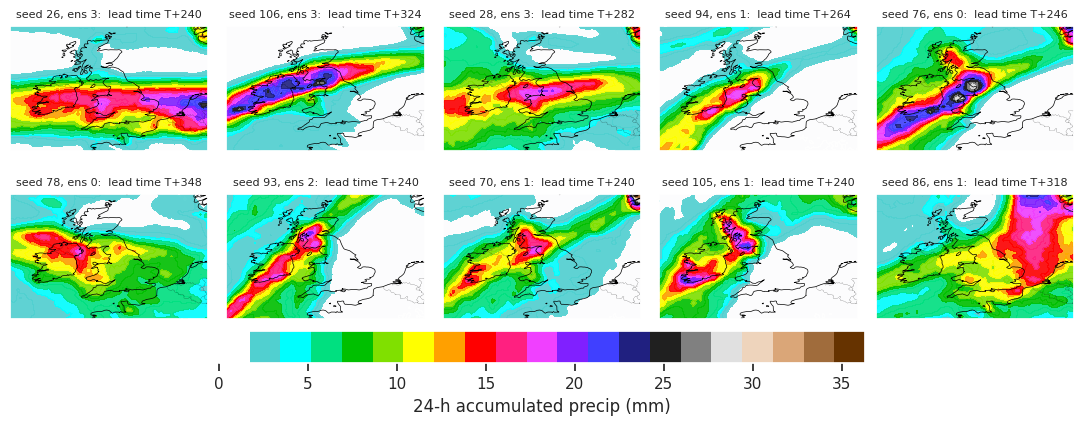

In [4]:
# Define small Dublin box for scoring (example bounds)
dublin_bbox = [-6.5, -6.0, 53.5, 53.2]   # [lonmin, lonmax, latmin, latmax]

# Define plotting domain for UK+Ireland
uk_bbox = [-12.5, 6.5, 60.0, 48.0]

if event_str == 'Desmond_seed76' or event_str == 'Desmond_seed76_v2': # top 5 forecasts
    ncols = 3
    top_k = 6
else: # top 10 forecasts for the larger ensemble ('Desmond')
    ncols = 5
    top_k = 10

# call the plotting function 
top_members, top_leads, fig, da_tp24 = pf.top_members_by_rolling_max(
    files,
    event_str=event_str,
    sampling_dims='member',
    lead_dim_hint='lead_time',
    rolling_window=None,
    min_periods=4,
    score_bbox=dublin_bbox,
    plot_bbox=uk_bbox,
    exclusion_window=2,
    top_k=top_k,
    cmap=pf.get_metpy_colourmap('precipitation'),
    crs=ccrs.PlateCarree(),
    ncols=ncols,
    panel_size=2.2, # 2.2
    compute_now=True,
    peak_window_hours=None)

# save figure
out_file = f'/mnt/data/output_plots/{event_str}_most_extreme_forecasts_for_Dublin.png'
fig.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)

## Call the same function again but with the new options activated 

- Identify the time of the most extreme rainfall in each ensemble member 
- Create a single distribution from all of these forecasts and output 
- We will later feed this data through our `map_return_period` function on `rdev01`

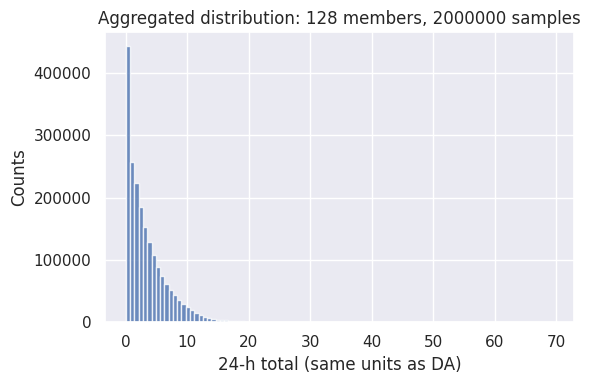

In [5]:
# call the plotting function 
top_members, peak_positions, fig_none, da_tp24, sfno_dist, fig_hist = pf.top_members_by_rolling_max(
    files,
    event_str=event_str,
    sampling_dims='member',
    lead_dim_hint='lead_time',
    rolling_window=None,
    min_periods=4,
    score_bbox=dublin_bbox,
    plot_bbox=uk_bbox,
    exclusion_window=2,
    top_k=top_k,
    cmap=pf.get_metpy_colourmap('precipitation'),
    crs=ccrs.PlateCarree(),
    ncols=ncols,
    panel_size=1.8, # 2.2
    compute_now=True,
    peak_window_hours=48,
    plot_distribution=True
)

## Produce the original postage stamp and most extreme plots 

In [7]:
# var = 'pr24'
# lead_time_list = list(np.arange(24,360,6))

# for lead_time in lead_time_list:
    # postage_stamp_plot = pf.produce_postage_stamp_plot(files,
    #                                                 var=var,
    #                                                 event_name='Desmond',
    #                                                 lead_time=lead_time)
    # stamp_out_file = f'/mnt/data/output_plots/{event_name}_{var}_postage_stamps_T{lead_time}.png'
    # postage_stamp_plot.savefig(stamp_out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)

    # # call the top 10 function and produce the output plot 
    # region_extent=[-11.5, 2.0, 60.0, 50.0]

    # top_members, fig, da_plot_lead = pf.find_and_plot_top_members(files, 
    #                                                               top_k=10,
    #                                                            score_kind='spatial_max',
    #                                                            region_extent=region_extent,
    #                                                            lead_time=lead_time)

    # out_file = f'/mnt/data/output_plots/{event_str}_{var}_most_extreme_forecasts_T{lead_time}.png'
    # fig.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0.02)

## Pre-process the ERA5 data to calculate 24-h accumulated precipitation

In [8]:
# repeat for precip data
era5_prcp_path = '/mnt/data/era5/era5_precip_041215_061215.grib'
ds_pr = xr.open_dataset(era5_prcp_path,engine='cfgrib')
ds_pr = pf.normalise_longitude(ds_pr, lon_name='longitude')

da = ds_pr['tp']
# convert units if needed (ERA5 often in metres -> mm)
if 'units' in da.attrs and 'm' in da.attrs['units'].lower():
    da = da * 1000.0
    da.attrs['units'] = 'mm'

if 'valid_time' in ds_pr.coords:
    valid_time_2d = ds_pr['valid_time'].values
else:
    # step may be timedelta64 or strings like '01:00:00'
    time_vals = ds_pr['time'].values     # shape (time,)
    step_vals = ds_pr['step'].values     # shape (step,)
    # If step is timedelta64, addition works; otherwise try to convert step to timedeltas
    if np.issubdtype(step_vals.dtype, np.timedelta64):
        valid_time_2d = time_vals[:, None] + step_vals[None, :]
    else:
        # try interpreting step as "HH:MM:SS" strings or integers hours
        try:
            step_td = np.array([np.timedelta64(int(str(s).split(':')[0]), 'h') if ':' in str(s) else np.timedelta64(int(s), 'h')
                                for s in step_vals])
            valid_time_2d = time_vals[:, None] + step_td[None, :]
        except Exception:
            raise RuntimeError("Couldn't interpret ds.step; inspect ds.step.dtype and values")

n_time, n_step = valid_time_2d.shape
# extract latitude/longitude arrays 
try:
    lon = ds_pr['lon'].values
except Exception: 
    lon = ds_pr['longitude'].values

try:
    lat = ds_pr['lat'].values
except Exception:
    lat = ds_pr['latitude'].values

data_flat = da.values.reshape(n_time * n_step, len(lat), len(lon)) # reshape from 4D to 3D (combine 'time' and 'step' dims)
valid_time_flat = valid_time_2d.ravel() # turn from 2D into 1D 

# build a DataArray indexed by 'valid_time'

da_hourly = xr.DataArray(
    data_flat,
    coords={'valid_time': ('valid_time', valid_time_flat),
            'latitude': ('latitude', lat),
            'longitude': ('longitude', lon)},
    dims=('valid_time', 'latitude', 'longitude'),
    attrs=da.attrs
)

da_hourly = da_hourly.sortby('valid_time')
da_hourly = da_hourly.groupby('valid_time').mean(dim='valid_time')

# resample to 24h sums aligned to right edge (so windows end at 00:00)
# label='right' and closed='right' makes the interval (t-24h, t] and labels it with t (the right edge).
tp24 = da_hourly.resample(valid_time='24h', label='right', closed='right').sum()

Ignoring index file '/mnt/data/era5/era5_precip_041215_061215.grib.5b7b6.idx' older than GRIB file


## Produce a plot of mslp and precip from ERA5 

Ignoring index file '/mnt/data/era5/era5_041215_061215.grib.5b7b6.idx' older than GRIB file


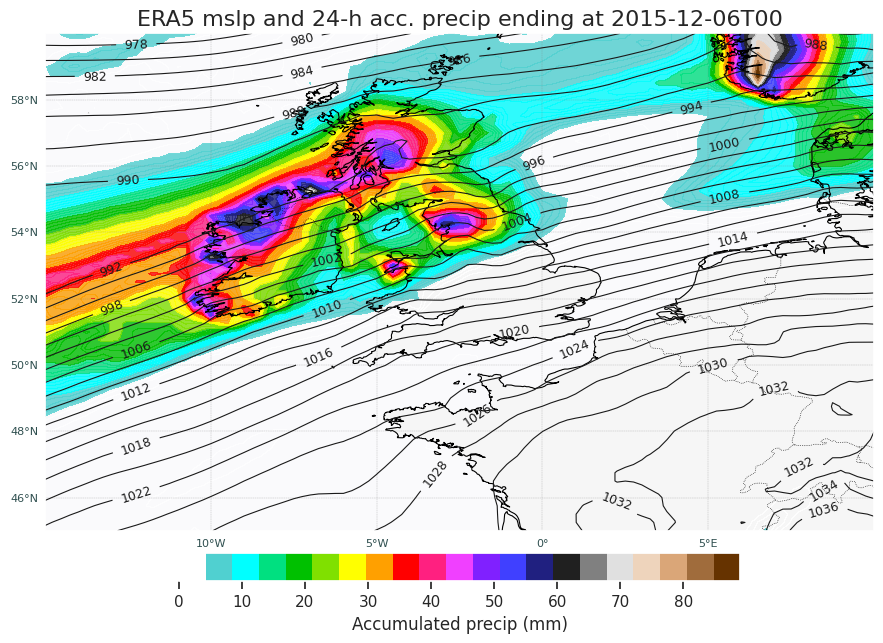

In [9]:
event_date_str = '2015-12-05T12'
event_date_sub = event_date_str.split(':')[0]
prcp_date_str = '2015-12-06T00'
crs = ccrs.PlateCarree()
cmap = pf.get_metpy_colourmap('precipitation')

# read in data from selected ensemble member and remove singleton dimension
era5_path = '/mnt/data/era5/era5_041215_061215.grib'
ds = xr.open_dataset(era5_path,engine='cfgrib')
ds = pf.normalise_longitude(ds, lon_name='longitude')
da = ds['msl'].sel(time=event_date_str)

# read in processed 24-h precip data (ending at 00Z on 6 December, i.e. 5 December)
da_pr = tp24.sel(valid_time=prcp_date_str)

# create 2D lat + lon arrays 
Lon, Lat = np.meshgrid(lon, lat)

# common function to add coastal features
def decorate(ax):
    #ax.set_extent(extent, crs=crs)
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', zorder=0)


# create a 'panel' plot with a single panel
fig, axes = plt.subplots(figsize=(9, 6),
                         subplot_kw={'projection': crs})

# Mean sea level pressure (pmsl)
ax = axes
decorate(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
# remove lat-lon labels on top and right axes 
try:
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True
except AttributeError:
    gl.xlabels_top = False
    gl.xlabels_bottom = True
    gl.ylabels_left = False
    gl.ylabels_right = True

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# make the lat/lon labels smaller and lighter
gl.xlabel_style = {'size': 8, 'color': 'darkslategray'}
gl.ylabel_style = {'size': 8, 'color': 'darkslategray'}

# Convert MSLP to hPa if it's in Pa (common). Check units attribute if available.
p = da.values.copy()
pr = da_pr.values.copy()
units = da.attrs.get('units', '').lower()
if 'pa' in units or (p.mean() > 2000):   # heuristic: values >> 1000 probably Pa
    p_hpa = p / 100.0
else:
    p_hpa = p

# make sensible contour levels (e.g. every 2 hPa)
p_min = np.nanmin(p_hpa)
p_max = np.nanmax(p_hpa)
interval = 2.0
levels = np.arange(np.floor(p_min / interval) * interval, np.ceil(p_max / interval) * interval + 1e-6, interval)

# repeat for precip
pr_min = np.nanmin(pr)
pr_max = np.nanmax(pr)
interval = 1.0
lev_min = np.floor(pr_min / interval)
lev_max = np.ceil(pr_max / interval)
pr_levels = np.arange(lev_min * interval, lev_max * interval + 1e-6, interval)

# add contour lines (isobars)
cs = ax.contour(Lon, Lat, p_hpa, levels=levels, colors='k', linewidths=0.8, transform=crs)
ax.clabel(cs, inline=True, fmt='%d', fontsize=9)
ax.set_title(f'ERA5 mslp and 24-h acc. precip ending at {prcp_date_str}',fontsize=16)

# also filled contour plot for precip
cs_pr = ax.contourf(Lon, Lat, pr, levels=pr_levels, cmap=cmap, alpha=0.8, transform=crs)
plt.tight_layout()

# add and customise colourbar 
norm = mcolors.Normalize(vmin=lev_min, vmax=lev_max)
sm = ScalarMappable(norm=norm, cmap=cmap)  # only used for colorbar scaling if you want
sm.set_array([])
# place colorbar below the whole figure
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
cbar.set_label('Accumulated precip (mm)')

out_file = f'/mnt/data/output_plots/{event_str}_{event_date_sub}_ERA5_mslp_24h_prcp.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight', pad_inches=0)